
Classificação de dígitos manuscritos com SVM
Tema: reconhecimento de dígitos manuscritos usando Support Vector Machine.


Biblioteca escolhida: Scikit-Learn
Algoritmo principal: SVC (Support Vector Classifier)

Este notebook aplica SVM para classificar imagens pequenas de números manuscritos de 0 a 9. O problema é de classificação multiclasse, pois cada imagem pertence a uma das dez classes possíveis.

A base usada é load_digits(), disponível diretamente no Scikit-Learn. Isso permite que o notebook rode no Kaggle sem precisar baixar arquivos externos.

nomes: Márcio Guilherme Ventola, João Gabriel, Lucas Queroz, Vinicius Baptista Amaral Monteiro

## 1. Importação das bibliotecas

Nesta etapa são importadas as bibliotecas necessárias para:

- carregar a base de dados;
- visualizar imagens;
- separar dados de treino e teste;
- padronizar as variáveis;
- treinar o SVM;
- avaliar o desempenho do modelo.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

np.random.seed(42)


## 2. Carregamento da base de dados

A base `load_digits()` contém imagens de dígitos manuscritos. Cada imagem possui dimensão 8 × 8 pixels, totalizando 64 variáveis numéricas por imagem.

Cada variável representa a intensidade de um pixel. O objetivo do modelo é aprender padrões nesses pixels para identificar qual número está representado.


In [2]:
digits = load_digits()

X = digits.data
y = digits.target

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)
print("Classes disponíveis:", np.unique(y))


Formato de X: (1797, 64)
Formato de y: (1797,)
Classes disponíveis: [0 1 2 3 4 5 6 7 8 9]


## 3. Visualização das imagens

Antes de treinar o modelo, é útil visualizar algumas imagens da base. Isso ajuda a entender o tipo de dado que está sendo analisado.

Embora o SVM receba os dados em formato tabular com 64 colunas, cada linha pode ser reconstruída como uma imagem 8 × 8.


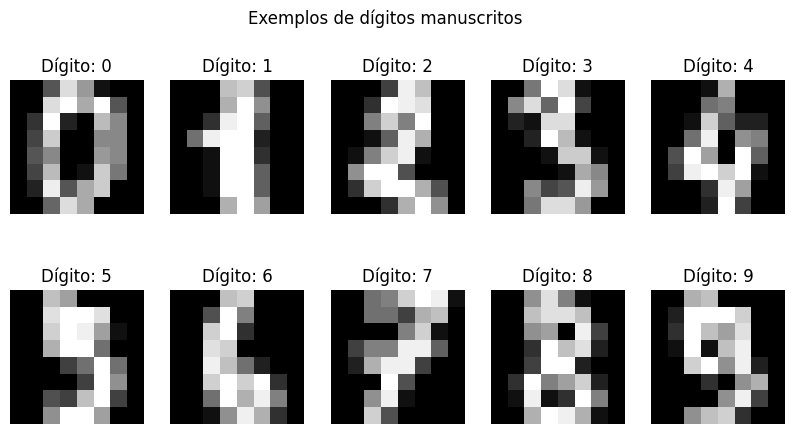

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for ax, image, label in zip(axes.ravel(), digits.images[:10], digits.target[:10]):
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Dígito: {label}")
    ax.axis("off")

plt.suptitle("Exemplos de dígitos manuscritos")
plt.show()


## 4. Divisão entre treino e teste

A base foi dividida em duas partes:

- **Treino:** usada para ensinar o modelo;
- **Teste:** usada para avaliar se o modelo aprendeu padrões generalizáveis.

Foi usada divisão estratificada para preservar a proporção de cada dígito nas duas partes.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Amostras de treino:", X_train.shape[0])
print("Amostras de teste:", X_test.shape[0])


Amostras de treino: 1257
Amostras de teste: 540


## 5. Treinamento inicial do SVM

O SVM é sensível à escala das variáveis. Por isso, foi utilizado `StandardScaler` antes do classificador.

Foi usado o kernel RBF, adequado para problemas em que a separação entre as classes pode ser não linear.


In [6]:
modelo_svm = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale"))
])

modelo_svm.fit(X_train, y_train)

y_pred = modelo_svm.predict(X_test)

acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia inicial do SVM: {acuracia:.4f}")


Acurácia inicial do SVM: 0.9833


## 6. Avaliação do modelo inicial

A avaliação usa:

- **Acurácia:** proporção geral de acertos;
- **Precision:** entre as previsões de uma classe, quantas estavam corretas;
- **Recall:** entre os exemplos reais de uma classe, quantos foram encontrados;
- **F1-score:** média harmônica entre precision e recall;
- **Matriz de confusão:** mostra quais dígitos foram confundidos.


In [ ]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=digits.target_names
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, values_format="d", cmap="Blues")
plt.title("Matriz de confusão - SVM inicial")
plt.show()


## 7. Ajuste de hiperparâmetros com GridSearchCV

O desempenho do SVM pode mudar de acordo com os hiperparâmetros:

- `C`: controla a penalização por erro;
- `gamma`: controla a influência de cada amostra;
- `kernel`: define a forma de separação entre as classes.

Foi utilizado `GridSearchCV` com validação cruzada para testar combinações e selecionar a melhor configuração.


In [ ]:
parametros = {
    "svm__kernel": ["linear", "rbf"],
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", "auto"]
}

busca = GridSearchCV(
    estimator=modelo_svm,
    param_grid=parametros,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

busca.fit(X_train, y_train)

print("Melhores parâmetros encontrados:")
print(busca.best_params_)
print(f"Melhor acurácia média na validação cruzada: {busca.best_score_:.4f}")


## 8. Avaliação do melhor modelo

Após o ajuste de hiperparâmetros, o melhor modelo é avaliado novamente na base de teste.

Essa etapa mostra se a busca melhorou o desempenho em dados que não foram usados durante o treinamento.


In [ ]:
melhor_modelo = busca.best_estimator_

y_pred_best = melhor_modelo.predict(X_test)

acuracia_final = accuracy_score(y_test, y_pred_best)
print(f"Acurácia final no teste: {acuracia_final:.4f}")

print(classification_report(y_test, y_pred_best))

cm_best = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best,
    display_labels=digits.target_names
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, values_format="d", cmap="Blues")
plt.title("Matriz de confusão - melhor SVM")
plt.show()


## 9. Visualização de previsões

A célula abaixo mostra algumas imagens da base de teste com a classe real e a classe prevista pelo modelo.

Isso torna o resultado mais interpretável, pois permite visualizar exemplos de acertos e possíveis erros.


In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(12, 7))

for ax, imagem_flat, real, pred in zip(axes.ravel(), X_test[:15], y_test[:15], y_pred_best[:15]):
    imagem = imagem_flat.reshape(8, 8)
    ax.imshow(imagem, cmap="gray")
    ax.set_title(f"Real: {real} | Previsto: {pred}")
    ax.axis("off")

plt.suptitle("Exemplos de previsões do modelo SVM")
plt.tight_layout()
plt.show()


## 10. Conclusão

Este notebook demonstrou o uso de SVM para classificação de dígitos manuscritos. O modelo utilizou as intensidades dos pixels como variáveis explicativas e aprendeu a classificar cada imagem em uma das classes de 0 a 9.

A biblioteca escolhida foi o **Scikit-Learn**, por ser amplamente utilizada em projetos de aprendizado de máquina e estar disponível em ambientes como o Kaggle Notebook.

O uso de SVM é adequado para esse tipo de problema porque o algoritmo busca separar classes por margens ótimas. Com o uso de padronização e ajuste de hiperparâmetros, o modelo tende a alcançar boa acurácia em bases de imagens simples, como a `load_digits()`.

**Resumo do projeto:**

- **Tema:** classificação de dígitos manuscritos;
- **Biblioteca:** Scikit-Learn;
- **Algoritmo:** SVM com `SVC`;
- **Técnicas usadas:** padronização, treino/teste, validação cruzada e matriz de confusão;
- **Ambiente recomendado:** Kaggle Notebook.
